# Bacterias atrapadas seis meses: el hidrogel que no las deja escapar

Pones bacterias modificadas dentro de tu cuerpo. Producen un antibiótico a demanda. Pasan **seis meses** y ninguna se escapa. Para hacernos una idea: la mediana de la literatura previa aguantaba apenas día y medio.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 120px
:align: center
:::

**Paper:** [Implantable living materials autonomously deliver therapeutics using contained engineered bacteria](https://doi.org/10.1126/science.aec2071)  
Harimoto T, et al. (corresponding: Mooney DJ). *Science* 392, 729 (2026).

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-14-hidrogel-bacterias-terapia/notebook.ipynb)

## El problema que llevaba años atascado

Las **terapias vivas** —bacterias modificadas que sintetizan medicinas dentro del cuerpo— prometen mucho. El obstáculo clínico: las bacterias siempre se escapan del hidrogel que las contiene. Los materiales previos fallaban a las pocas horas o, en el mejor caso, a las pocas semanas.

El equipo del laboratorio de David Mooney en Harvard recopiló los datos de contención de **24 estudios previos** y los puso al lado del suyo. Vamos a abrir esos números, comparar materiales, ver cómo cambian rigidez y tenacidad del nuevo hidrogel, y ver también las mutaciones que aparecen en las bacterias atrapadas — porque la honestidad del paper también incluye lo que sí degenera.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CONTAINMENT_ESTE_ESTUDIO = 4320   # horas (= 180 días = 6 meses)
MEDIANA_PREVIA = 36                # horas — mediana literatura
MEJOR_PREVIO = 504                 # horas — PVA vinyl sulfone, Maharjan 2024
FUENTE = ('Fuente: Harimoto et al. (2026), Science | '
          'Datos: Supplementary Materials, Tables S1-S4')
COLOR_DATOS = '#2563EB'        # azul CaM — datos de literatura
COLOR_ALERTA = '#DC2626'       # rojo — este estudio
COLOR_REFERENCIA = '#D97706'   # ámbar — mediana / umbral
COLOR_GRIS = '#BBBBBB'         # neutro — contexto secundario

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cargar estilo CaM (local → fallback raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Cargar los cuatro CSVs transcritos del Supplementary PDF
containment = pd.read_csv('datos/containment_time.csv')
mech = pd.read_csv('datos/mechanical_properties.csv')
mut_summary = pd.read_csv('datos/mutations_summary.csv')
mut_colony = pd.read_csv('datos/mutations_per_colony.csv')

print(f'containment_time: {len(containment)} estudios '
      f'(24 previos + 1 este = {len(containment)})')
print(f'mechanical_properties: {len(mech)} formulaciones de hidrogel')
print(f'  · PVA (este estudio): {(mech["source"]=="This study").sum()} muestras')
print(f'  · Literatura previa: {(mech["source"]!="This study").sum()} muestras')
print(f'mutations_summary: {mut_summary["count"].sum()} mutaciones totales')
print(f'mutations_per_colony: {mut_colony["colony"].nunique()} colonias con al menos una mutación')

containment_time: 25 estudios (24 previos + 1 este = 25)
mechanical_properties: 66 formulaciones de hidrogel
  · PVA (este estudio): 31 muestras
  · Literatura previa: 35 muestras
mutations_summary: 51 mutaciones totales
mutations_per_colony: 31 colonias con al menos una mutación


## Aquí está.

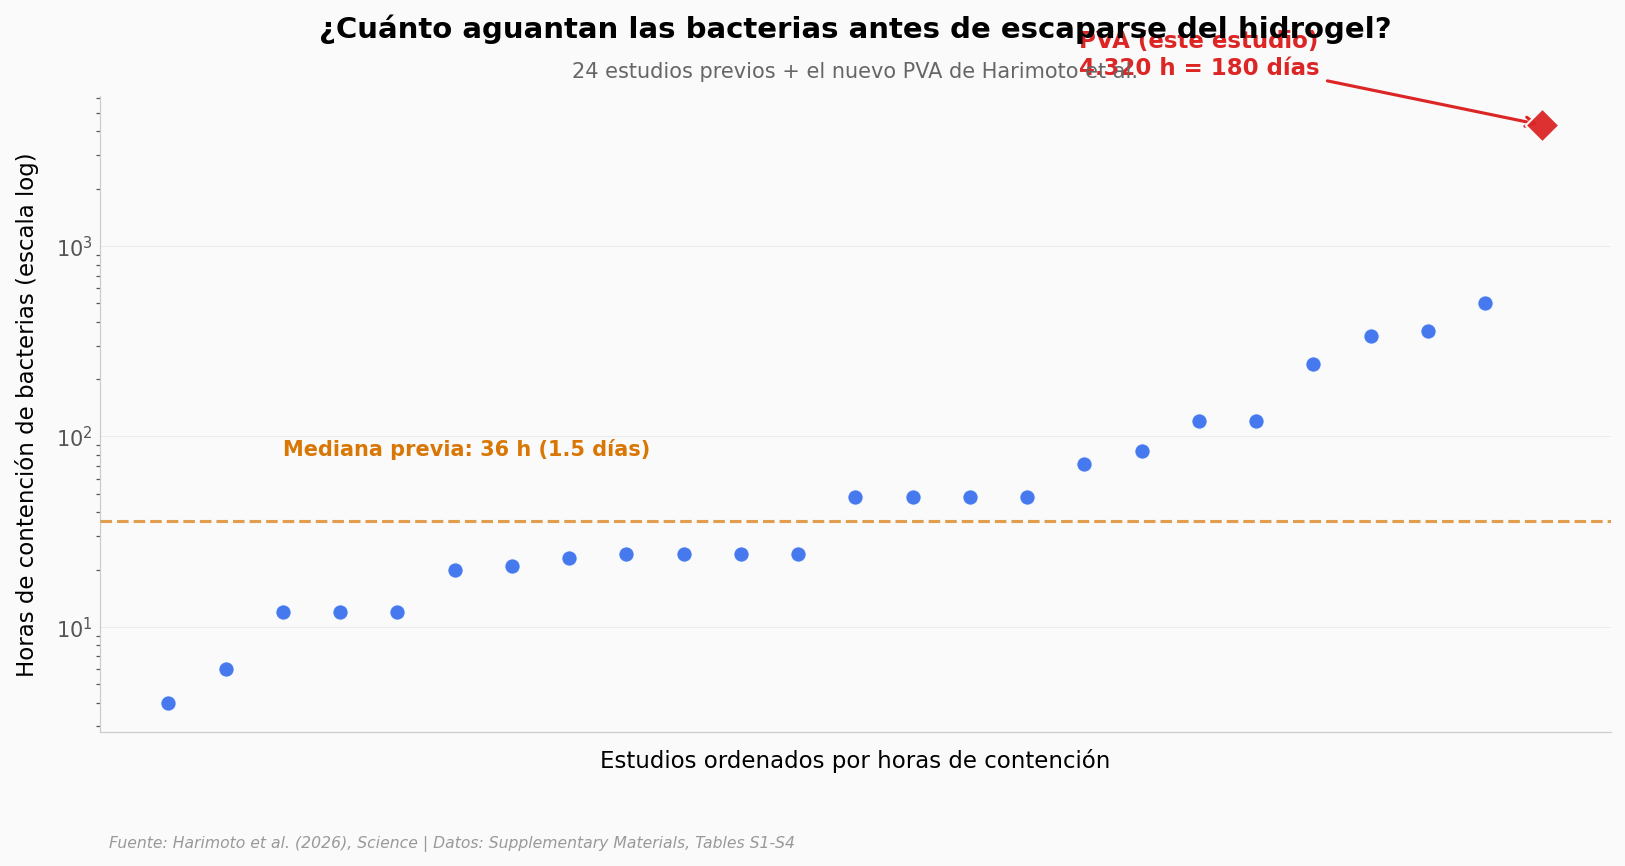

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Separar previos (azul) y este estudio (rojo)
prev = containment[containment['reference'] != 'This study'].copy()
este = containment[containment['reference'] == 'This study'].copy()

# Orden por horas para que la nube se lea izquierda→derecha
prev = prev.sort_values('containment_hours').reset_index(drop=True)
x_prev = np.arange(len(prev))
x_este = len(prev)

ax.scatter(x_prev, prev['containment_hours'], color=COLOR_DATOS,
           s=55, alpha=0.85, edgecolors='white', linewidths=0.6,
           zorder=5)
ax.scatter([x_este], este['containment_hours'], color=COLOR_ALERTA,
           s=130, alpha=0.95, edgecolors='white', linewidths=1.0,
           zorder=6, marker='D')

# Línea horizontal en la mediana previa
ax.axhline(y=MEDIANA_PREVIA, color=COLOR_REFERENCIA, linewidth=1.5,
           linestyle='--', alpha=0.7, zorder=3)
ax.annotate(f'Mediana previa: {MEDIANA_PREVIA} h ({MEDIANA_PREVIA/24:.1f} días)',
            xy=(0.5, MEDIANA_PREVIA), xytext=(2, MEDIANA_PREVIA*2.2),
            fontsize=10, fontweight='bold', color=COLOR_REFERENCIA)

# Etiqueta inline del estudio nuevo
ax.annotate('PVA (este estudio)\n4.320 h = 180 días',
            xy=(x_este, este['containment_hours'].iloc[0]),
            xytext=(x_este - 6, 8000),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_yscale('log')
ax.set_ylabel('Horas de contención de bacterias (escala log)', fontsize=11)
ax.set_xlabel('Estudios ordenados por horas de contención', fontsize=11)
ax.set_title('¿Cuánto aguantan las bacterias antes de escaparse del hidrogel?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '24 estudios previos + el nuevo PVA de Harimoto et al.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks([])

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_containment_hero.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que llama la atención:**

- La nube azul recorre desde 4 horas hasta poco más de 500 horas. La gran mayoría no pasa de los dos días.
- El **mejor previo** (PVA vinyl sulfone para lentes de contacto, Maharjan 2024) llegó a 504 horas — tres semanas escasas.
- El nuevo punto rojo está en otro plano: 4.320 horas, seis meses completos. La escala es logarítmica; el salto real es brutal.

Hay que decirlo: este es un único punto frente a una mediana de 24 estudios. No es estadística inferencial — es una marca técnica nueva. Que el siguiente equipo replique seis meses con otra cepa y otro modelo es la prueba que viene.

## ¿Y mecánicamente?

Aguantar seis meses sin escapes no es solo cuestión de poros pequeños. El hidrogel también tiene que **no romperse** bajo el movimiento del cuerpo. Dos propiedades importan a la vez: la rigidez (modulus, qué tan duro es) y la tenacidad (work of fracture, cuánta energía absorbe antes de partirse). Veamos cómo se compara el nuevo PVA contra 35 formulaciones de otros materiales reportadas en la literatura.

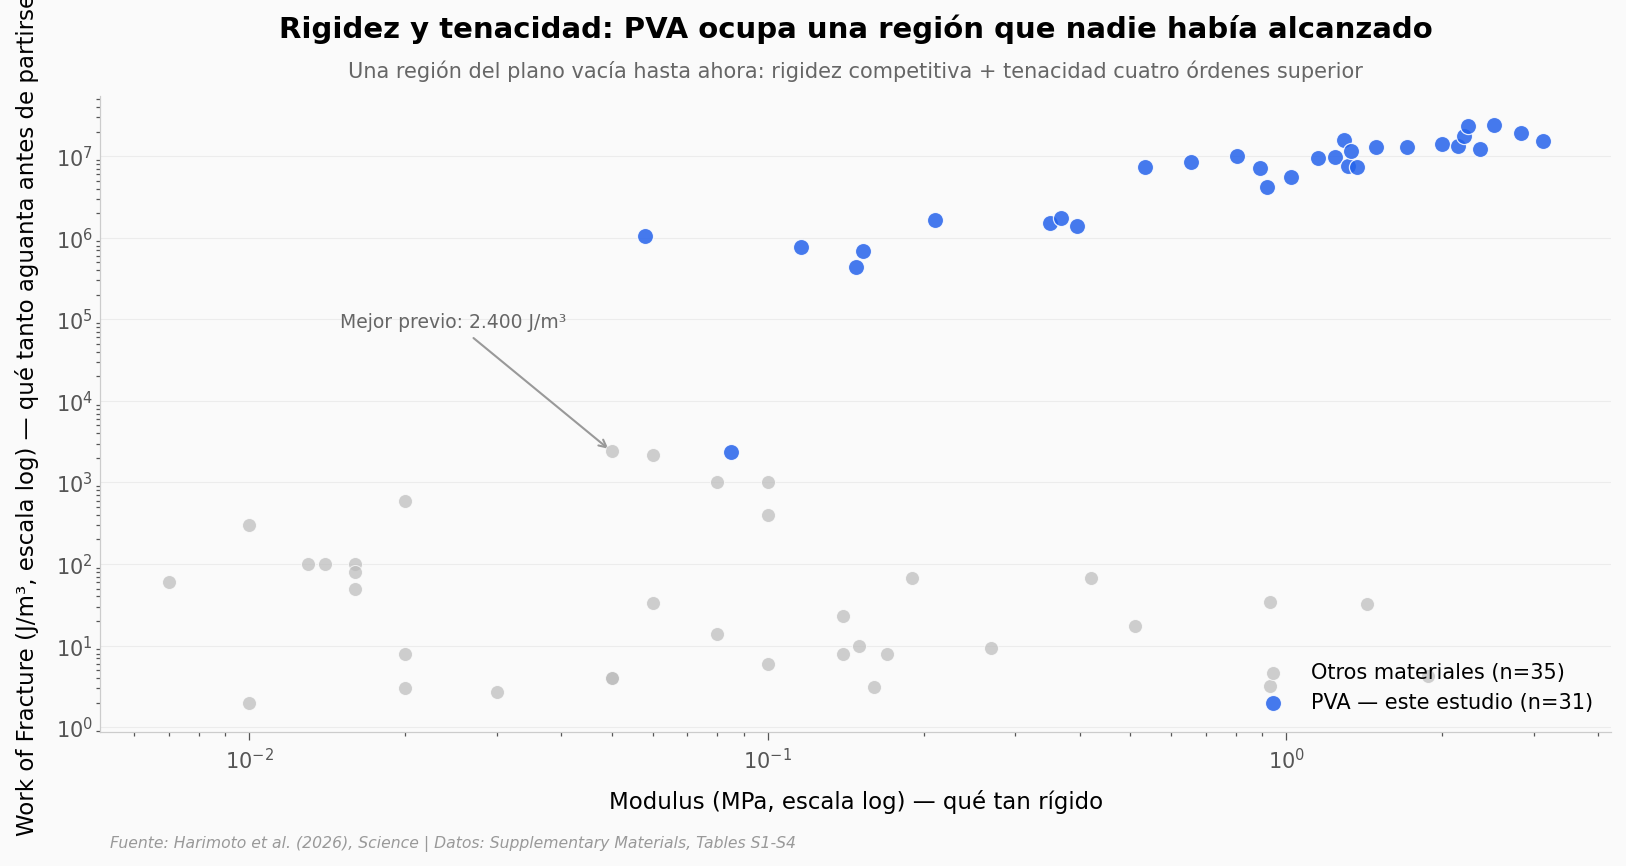

PVA — Modulus: 0.058 a 3.12 MPa (mediana 1.15)
PVA — Work of fracture máx: 24.010.000 J/m³
Mejor previo (no-PVA): 2.400 J/m³
Razón: ~10.004x — cuatro órdenes de magnitud


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

pva = mech[mech['source'] == 'This study'].copy()
otros = mech[mech['source'] != 'This study'].copy()

# Otros materiales (literatura previa) — gris
ax.scatter(otros['modulus_mpa'], otros['work_of_fracture_jm3'],
           color=COLOR_GRIS, s=45, alpha=0.7,
           edgecolors='white', linewidths=0.5, zorder=4,
           label=f'Otros materiales (n={len(otros)})')

# PVA de este estudio — azul
ax.scatter(pva['modulus_mpa'], pva['work_of_fracture_jm3'],
           color=COLOR_DATOS, s=60, alpha=0.85,
           edgecolors='white', linewidths=0.6, zorder=5,
           label=f'PVA — este estudio (n={len(pva)})')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Modulus (MPa, escala log) — qué tan rígido', fontsize=11)
ax.set_ylabel('Work of Fracture (J/m³, escala log) — qué tanto aguanta antes de partirse',
              fontsize=11)
ax.set_title('Rigidez y tenacidad: PVA ocupa una región que nadie había alcanzado',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Una región del plano vacía hasta ahora: rigidez competitiva + tenacidad cuatro órdenes superior',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='lower right', framealpha=0.9)

# Marca del mejor competidor en tenacidad
best_other = otros.loc[otros['work_of_fracture_jm3'].idxmax()]
ax.annotate(f'Mejor previo: {int(best_other["work_of_fracture_jm3"]):,} J/m³'.replace(',', '.'),
            xy=(best_other['modulus_mpa'], best_other['work_of_fracture_jm3']),
            xytext=(0.015, 80000),
            fontsize=9, color='#666666',
            arrowprops=dict(arrowstyle='->', color='#999999', lw=1.0))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_modulus_vs_toughness.png', dpi=200, bbox_inches='tight')
plt.show()

# Resumen numérico
pva_max_wof = pva['work_of_fracture_jm3'].max()
otros_max_wof = otros['work_of_fracture_jm3'].max()
ratio = pva_max_wof / otros_max_wof
pva_max_wof_str = f'{int(pva_max_wof):,}'.replace(',', '.')
otros_max_wof_str = f'{int(otros_max_wof):,}'.replace(',', '.')
print(f'PVA — Modulus: {pva["modulus_mpa"].min():.3f} a '
      f'{pva["modulus_mpa"].max():.2f} MPa (mediana {pva["modulus_mpa"].median():.2f})')
print(f'PVA — Work of fracture máx: {pva_max_wof_str} J/m³')
print(f'Mejor previo (no-PVA): {otros_max_wof_str} J/m³')
print(f'Razón: ~{ratio:,.0f}x'.replace(',', '.') + ' — cuatro órdenes de magnitud')

## Lo que sí degrada con el tiempo: el ADN

El hidrogel aguanta seis meses. Las bacterias dentro, no tanto. El equipo secuenció colonias recuperadas tras el experimento y catalogó **51 mutaciones en 31 colonias**. La mayoría caen en la región que codifica el medicamento (el CDS de ChPy — el gen 'carga útil' que produce la terapia), pero también hay deleciones del gen completo: en algunas colonias el medicamento dejó de producirse. La contención física ganó; la función terapéutica tiene fecha de caducidad.

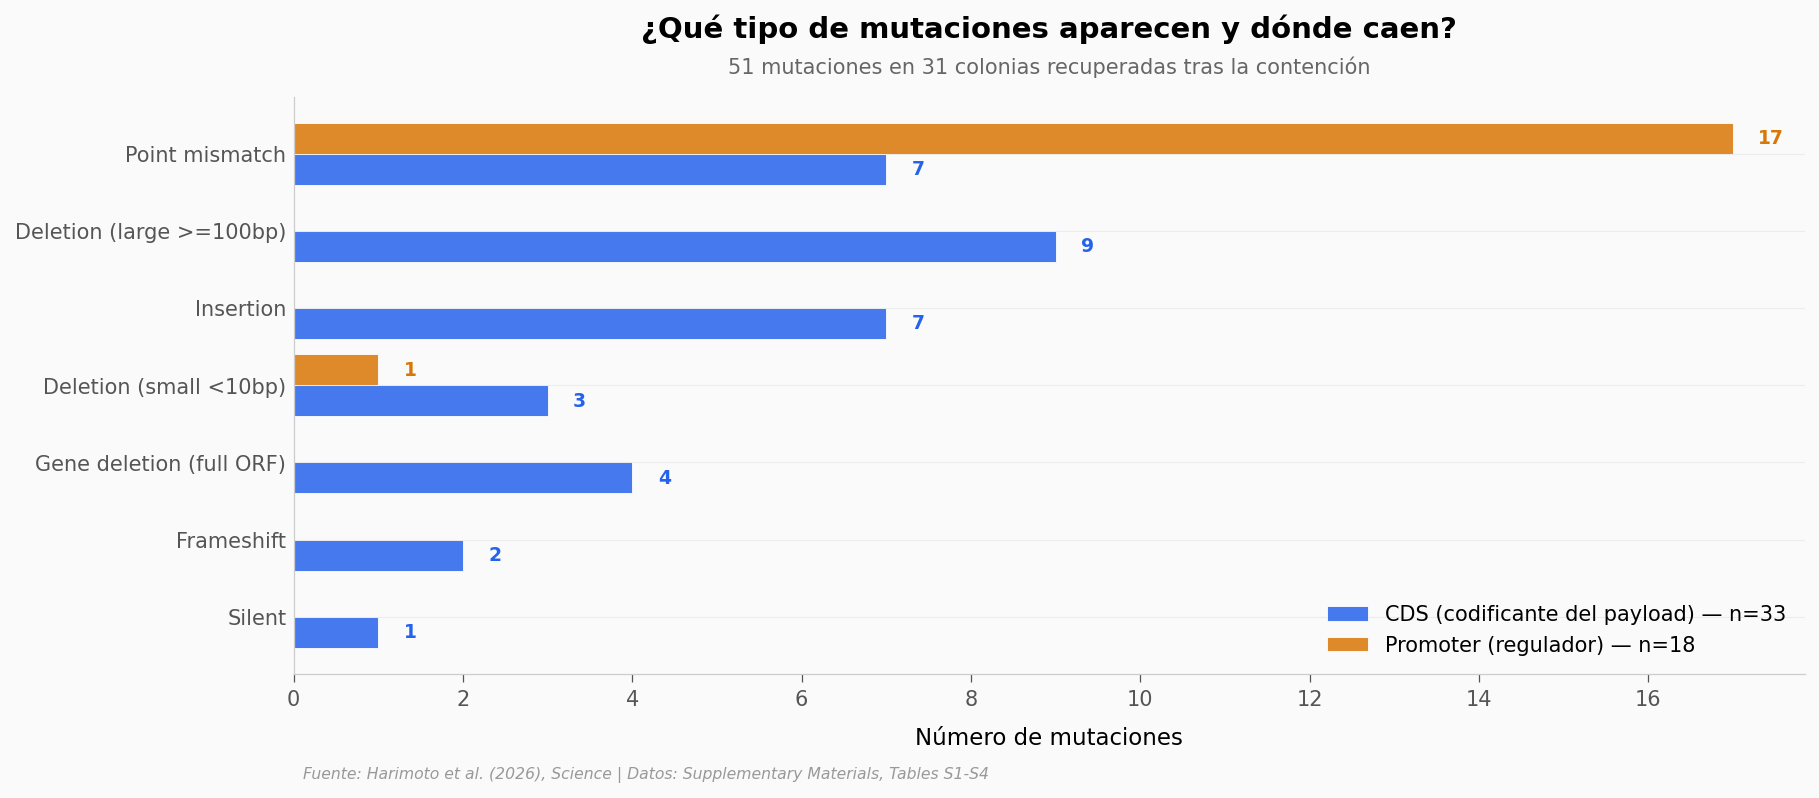

Deleciones de gen completo (Gene deletion, full ORF): 4 de 51 mutaciones (7.8%).
En esas colonias el ORF del payload desaparece — el medicamento deja de producirse.


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.0))

# Pivot: filas = tipo de mutación, columnas = elemento
piv = mut_summary.pivot(index='mutation_type', columns='element',
                        values='count').fillna(0)

# Orden de tipos (los más comunes arriba)
orden = piv.sum(axis=1).sort_values(ascending=True).index
piv = piv.loc[orden]

y = np.arange(len(piv))
bar_h = 0.4
cds_vals = piv['ChPy CDS'].values
prom_vals = piv['Promoter'].values

ax.barh(y - bar_h/2, cds_vals, height=bar_h, color=COLOR_DATOS, alpha=0.85,
        label=f'CDS (codificante del payload) — n={int(cds_vals.sum())}',
        edgecolor='white', linewidth=0.5)
ax.barh(y + bar_h/2, prom_vals, height=bar_h, color=COLOR_REFERENCIA, alpha=0.85,
        label=f'Promoter (regulador) — n={int(prom_vals.sum())}',
        edgecolor='white', linewidth=0.5)

# Anotar conteos
for i, (c, p) in enumerate(zip(cds_vals, prom_vals)):
    if c > 0:
        ax.text(c + 0.3, i - bar_h/2, str(int(c)), va='center',
                fontsize=9, color=COLOR_DATOS, fontweight='bold')
    if p > 0:
        ax.text(p + 0.3, i + bar_h/2, str(int(p)), va='center',
                fontsize=9, color=COLOR_REFERENCIA, fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(piv.index, fontsize=10)
ax.set_xlabel('Número de mutaciones', fontsize=11)
ax.set_title('¿Qué tipo de mutaciones aparecen y dónde caen?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.04, '51 mutaciones en 31 colonias recuperadas tras la contención',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='lower right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_mutations_by_element.png', dpi=200, bbox_inches='tight')
plt.show()

is_gene_del = mut_summary['mutation_type'].str.startswith('Gene deletion')
deletions = int(mut_summary.loc[is_gene_del, 'count'].sum())
total = int(mut_summary['count'].sum())
print(f'Deleciones de gen completo (Gene deletion, full ORF): {deletions} de {total} '
      f'mutaciones ({100*deletions/total:.1f}%).')
print('En esas colonias el ORF del payload desaparece — el medicamento deja de producirse.')

## ¿Qué tan extremo es este punto?

Volvamos a la pregunta del título. Si dibujamos la distribución de horas de contención de los 24 estudios previos como un histograma y marcamos dónde cae el nuevo PVA, el resultado se ve así:

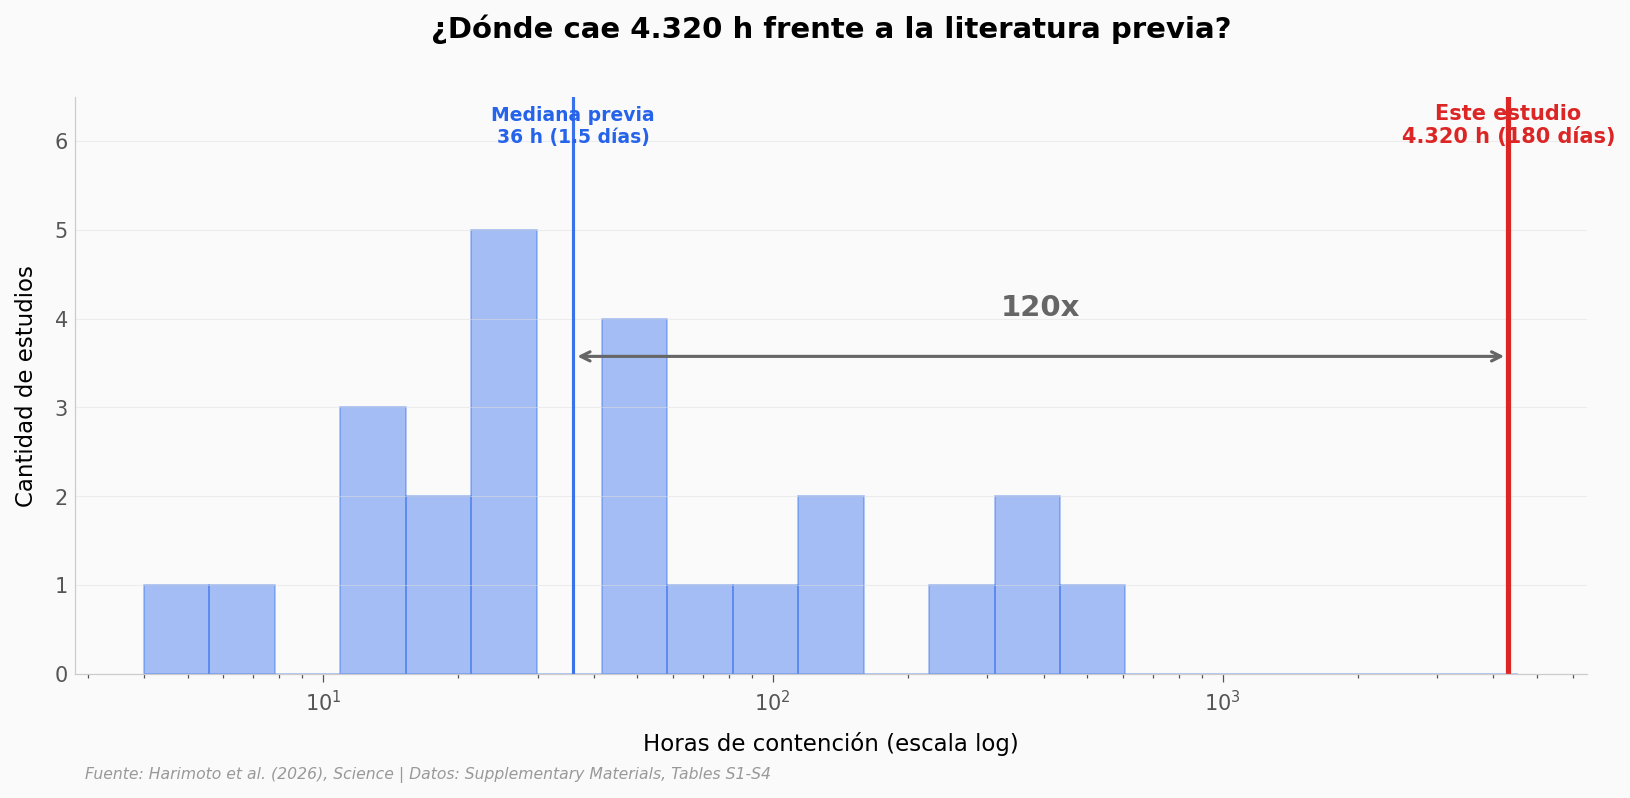

Mediana literatura previa: 36 h (1.5 días)
Este estudio:              4.320 h (180 días)
Razón este/mediana:        120x
Razón este/mejor previo:   8.6x


In [5]:
fig, ax = plt.subplots(figsize=(13, 5.0))

prev_hours = containment.loc[
    containment['reference'] != 'This study', 'containment_hours'].values
este_hours = CONTAINMENT_ESTE_ESTUDIO

# Escala logarítmica del eje X — los datos abarcan 4-4320 h
bins = np.logspace(np.log10(prev_hours.min()),
                   np.log10(este_hours * 1.05), 22)
n, _, _ = ax.hist(prev_hours, bins=bins, color=COLOR_DATOS, alpha=0.4,
                  edgecolor=COLOR_DATOS, linewidth=0.8,
                  label=f'24 estudios previos')
y_max = max(n) * 1.30
ax.set_ylim(0, y_max)
ax.set_xscale('log')

mediana_prev = float(np.median(prev_hours))
ax.axvline(x=mediana_prev, color=COLOR_DATOS, linewidth=1.5, alpha=0.9)
ax.axvline(x=este_hours, color=COLOR_ALERTA, linewidth=2.5)

ax.text(mediana_prev, y_max * 0.92,
        f'Mediana previa\n{mediana_prev:.0f} h ({mediana_prev/24:.1f} días)',
        ha='center', fontsize=9, color=COLOR_DATOS, fontweight='bold')
ax.text(este_hours, y_max * 0.92,
        f'Este estudio\n{este_hours:,} h ({este_hours/24:.0f} días)'.replace(',', '.'),
        ha='center', fontsize=10, color=COLOR_ALERTA, fontweight='bold')

# Flecha bidireccional entre mediana y este
ax.annotate('', xy=(este_hours, y_max*0.55),
            xytext=(mediana_prev, y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ratio = este_hours / mediana_prev
geom_mean_x = np.sqrt(mediana_prev * este_hours)
ax.text(geom_mean_x, y_max*0.62,
        f'{ratio:.0f}x',
        ha='center', fontsize=14, color='#666666', fontweight='bold')

ax.set_xlabel('Horas de contención (escala log)', fontsize=11)
ax.set_ylabel('Cantidad de estudios', fontsize=11)
ax.set_title('¿Dónde cae 4.320 h frente a la literatura previa?',
             fontsize=14, fontweight='bold', pad=28)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_anomalia_containment.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Mediana literatura previa: {mediana_prev:.0f} h ({mediana_prev/24:.1f} días)')
print(f'Este estudio:              {este_hours:,} h ({este_hours/24:.0f} días)'.replace(',', '.'))
print(f'Razón este/mediana:        {ratio:.0f}x')
print(f'Razón este/mejor previo:   {este_hours/MEJOR_PREVIO:.1f}x')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| 6 meses (4.320 h) de contención sin escapes | ✅ | Última fila de Table S1; el paper lo enmarca como afirmación directa (`achieved`). |
| 120x sobre la mediana previa | ✅ | 4320/36 = 120, calculado sobre las 24 entradas previas de Table S1. |
| 8.6x sobre el mejor previo (504 h, PVA vinyl sulfone) | ✅ | Aritmética directa sobre Table S1. |
| Modulus de hasta 3.12 MPa | ✅ | Table S2 row 65 (30% PVA + 0.1 M phytate). Rango total PVA: 0.058–3.124 MPa, n=31. |
| Tenacidad ~10.000x sobre el mejor no-PVA | ✅ | 2.4·10⁷ / 2.400 = 10.004. Cálculo sobre Table S2. |
| 51 mutaciones en 31 colonias, 8% deleciones de gen | ✅ | Suma directa de Table S4. |
| Modelo murino de infección de articulación protésica | ✅ | Abstract + Methods (CT26 cells transfectadas con iRFP670, P. aeruginosa). |

> **Limitaciones que conviene tener presentes:**
> - Seis meses en ratón no son seis meses en humano. Falta validación clínica.
> - El 8% de deleciones de gen muestra que **la función terapéutica caduca** aunque la contención no.
> - Table S2 mezcla datos experimentales propios con valores aproximados leídos de figuras publicadas (marcados en la columna `approximate` del CSV).
> - Una sola entrada de PVA frente a 24 previas: no es estadística inferencial; es una marca técnica nueva que espera replicación.
> - El resumen por tipo de mutación (Table S4) suma 51 eventos, mientras que el detalle por colonia suma 59. La diferencia probablemente refleja eventos compuestos contados como uno solo en el resumen. No tenemos forma de resolverla sin volver al PDF original.
> - No hay datasets externos en Zenodo/Figshare/Dryad/OSF. Toda la reproducibilidad depende de las tablas transcritas del Supplementary PDF.

## Ahora tú

1. **¿Qué pasa si excluyes los estudios de "data storage" y "biosensing"?** Esas aplicaciones tienen otra exigencia de contención. Filtra `application` y vuelve a calcular la mediana.
2. **¿En qué condiciones experimentales aparece la mejor combinación rigidez+tenacidad?** Las muestras PVA con `phytate` parecen subir ambas. Léelo desde la columna `condition`.
3. **¿Cuántas colonias tienen más de una mutación?** Mira `mutations_per_colony.csv` y agrupa por `colony`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: contención por aplicación (excluyendo data storage y biosensing)
subset = containment[~containment['application'].isin(
    ['Data storage', 'Biosensing'])].copy()
subset_prev = subset[subset['reference'] != 'This study']
print('Tras excluir data storage y biosensing:')
print(f'  Estudios previos restantes: {len(subset_prev)}')
print(f'  Mediana de horas:           {subset_prev["containment_hours"].median():.0f} h')
print(f'  Máximo previo:              {subset_prev["containment_hours"].max():.0f} h')
print()
# Pregunta 3: colonias con más de una mutación
multi = mut_colony.groupby('colony')['n_mutations'].sum()
print(f'Colonias con >1 mutación: {(multi > 1).sum()} de {len(multi)} colonias.')
print(f'Máximo de mutaciones en una sola colonia: {multi.max()}')

Tras excluir data storage y biosensing:
  Estudios previos restantes: 22
  Mediana de horas:           36 h
  Máximo previo:              504 h

Colonias con >1 mutación: 13 de 31 colonias.
Máximo de mutaciones en una sola colonia: 5


---

## Fuentes

**Paper**: [Implantable living materials autonomously deliver therapeutics using contained engineered bacteria](https://doi.org/10.1126/science.aec2071)  
*Science, 2026-05-14 · paywall*

**Supplementary Material**: [PDF — Tables S1-S6, Figs. S1-S36](https://www.science.org/doi/suppl/10.1126/science.aec2071/suppl_file/science.aec2071_sm.pdf)  
*Science, 2026-05-14 · acceso abierto*

*18 afirmaciones del notebook verificadas contra estas fuentes*

## Créditos

- **Notebook:** Ciencia a Mordiscos · El Lab — [repo en GitHub](https://github.com/Ciencia-a-Mordiscos/lab)
- **Datos:** Transcritos manualmente del Supplementary PDF (Tables S1–S4) del paper.
- **Licencia notebook:** CC BY 4.0
- **Video del canal:** Pendiente
